# Comprehensive Dataset Analysis for Thesis

This notebook provides a thorough analysis of a temporal graph dataset. It is designed to generate high-quality figures, tables, and metrics suitable for direct inclusion in a thesis.

The analysis is structured as follows:
1.  **Setup and Data Loading**: Importing libraries and loading the datasets.
2.  **Cross-Dataset Sanity Checks**: Comparing high-level statistics across Train, Validation, and Test sets to ensure they are drawn from similar distributions. This is crucial for validating the data splitting process.
3.  **Deep Feature Analysis**: A detailed examination of the node features in the training set, including their statistical properties, distributions, and correlations.
4.  **Graph Structure Analysis**: An in-depth look at the graph's topological properties, including sparsity, degree distributions, connectivity, and centrality.
5.  **Temporal Analysis**: Investigating how graph and feature properties evolve over time to justify the use of temporal models.
6.  **Homophily Analysis**: Measuring the tendency of nodes to connect to other nodes with the same class label.

## 1. Setup and Data Loading

We begin by importing the necessary libraries, configuring the plotting style for thesis-quality figures, and loading the train, validation, and test datasets using our `MarketAnalyzer` utility class.

In [2]:
# Import required libraries
import sys
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from scipy.stats import entropy

# Add the project root to the Python path to allow importing dataset_analyzer
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from dataset_analyzer import MarketAnalyzer

# Set plot style for thesis-quality figures
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams['figure.figsize'] = (10, 6)
FIGURE_OUTPUT_PATH = Path('./thesis_figures_final')
FIGURE_OUTPUT_PATH.mkdir(exist_ok=True)

def save_figure(filename):
    """Helper function to save figures in a consistent format."""
    plt.savefig(FIGURE_OUTPUT_PATH / f"{filename}.pdf", format='pdf', bbox_inches='tight')
    plt.savefig(FIGURE_OUTPUT_PATH / f"{filename}.png", format='png', bbox_inches='tight', dpi=300)
    print(f"Figure saved to {FIGURE_OUTPUT_PATH / f'{filename}.pdf'}")

# --- Configuration ---
MARKET = 'SSE'
NORMALIZATION = 'log1p'
WINDOW_SIZE = 14

# Define dataset paths
base_path = project_root / 'data' / 'datasets' / 'graph'
train_path = base_path / f"{MARKET}_Train_2016-05-01_2017-06-30_{WINDOW_SIZE}_{NORMALIZATION}"
val_path = base_path / f"{MARKET}_Validation_2017-07-01_2017-12-31_{WINDOW_SIZE}_{NORMALIZATION}"
test_path = base_path / f"{MARKET}_Test_2018-01-01_2019-12-31_{WINDOW_SIZE}_{NORMALIZATION}"

# Load datasets using the MarketAnalyzer
# Set adj_minmax=True and a threshold if you want to prune the graph based on edge weights
train_analyzer = MarketAnalyzer(train_path, adj_minmax=False)
val_analyzer = MarketAnalyzer(val_path, train_path=train_path, adj_minmax=False)
test_analyzer = MarketAnalyzer(test_path, train_path=train_path, adj_minmax=False)

analyzers = {'Train': train_analyzer, 'Validation': val_analyzer, 'Test': test_analyzer}

print("Datasets loaded successfully.")

|             Dataset Information             |
| Market Name:         SSE                     |
| Time Period:         Train                   |
| Start Date:          2016-05-01              |
| End Date:            2017-06-30              |
| Window Size:         14                      |
| Normalizer:          log1p                   |
| Number of Features:  5                       |
| Number of Nodes:     128                     |
| Number of Snapshots: 102                     |
Folder analysis_results created at /extra/mbisoffi/tests/TemporalGNNReview/code/data/datasets/graph/SSE_Train_2016-05-01_2017-06-30_14_log1p
|             Dataset Information             |
| Market Name:         SSE                     |
| Time Period:         Validation              |
| Start Date:          2017-07-01              |
| End Date:            2017-12-31              |
| Window Size:         14                      |
| Normalizer:          log1p                   |
| Number of Features:  5    

FileNotFoundError: [Errno 2] No such file or directory: '/extra/mbisoffi/tests/TemporalGNNReview/code/data/datasets/graph/SSE_Validation_2017-07-01_2017-12-31_14_log1p/ticker_index_mapping.json'

## 2. Cross-Dataset Sanity Checks

**Motivation**: Before training any model, it's critical to verify that the training, validation, and test sets are statistically similar. Significant differences could indicate a flawed data splitting process (e.g., data leakage or domain shift), which would lead to misleading evaluation results. Here, we compare high-level distributions across the splits.

In [ ]:
# --- 2.1. Degree Distribution Comparison ---
# Motivation: Checks if the overall graph structure is consistent across splits.
plt.figure(figsize=(12, 6))
for name, analyzer in analyzers.items():
    in_degrees, out_degrees, _, _ = analyzer.get_degree_dist()
    sns.kdeplot(in_degrees, label=f'{name} In-Degree', fill=True, alpha=0.3)
    sns.kdeplot(out_degrees, label=f'{name} Out-Degree', linestyle='--', alpha=0.8)
plt.title('Degree Distribution Comparison Across Datasets')
plt.xlabel('Degree')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
save_figure('cross_dataset_degree_distribution')
plt.show()


Figure saved to thesis_figures_final/cross_dataset_feature_distribution.pdf


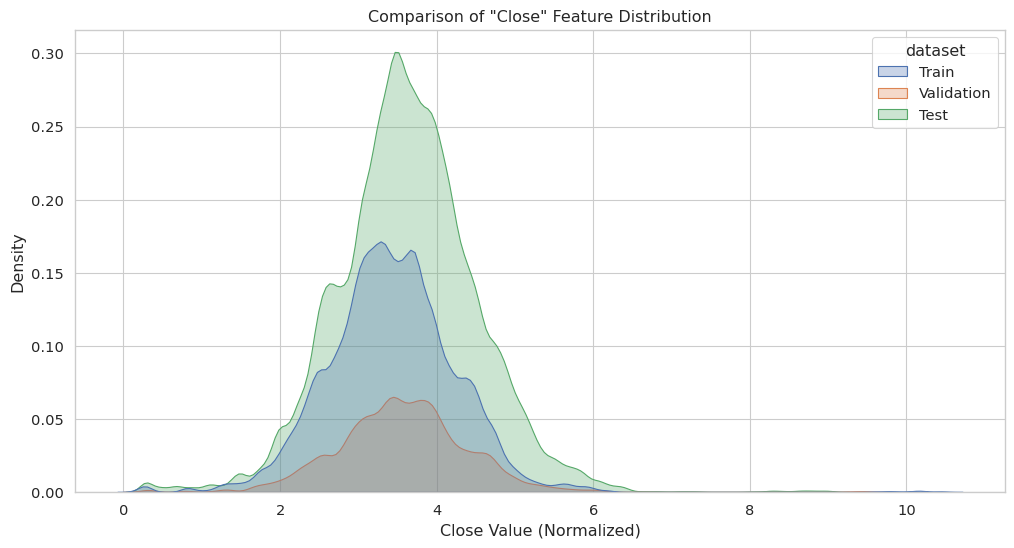

In [2]:
# --- 2.2. Feature Distribution Comparison (using 'Close' as an example) ---
# Motivation: Ensures that the feature values have a similar range and shape across splits.
feature_data = []
for name, analyzer in analyzers.items():
    df = analyzer.analyze_node_features()
    df['dataset'] = name
    feature_data.append(df)

full_feature_df = pd.concat(feature_data)
plt.figure(figsize=(12, 6))
sns.kdeplot(data=full_feature_df, x='Close', hue='dataset', fill=True, alpha=0.3)
plt.title('Comparison of "Close" Feature Distribution')
plt.xlabel('Close Value (Normalized)')
plt.ylabel('Density')
plt.grid(True)
save_figure('cross_dataset_feature_distribution')
plt.show()

Figure saved to thesis_figures_final/cross_dataset_class_distribution.pdf


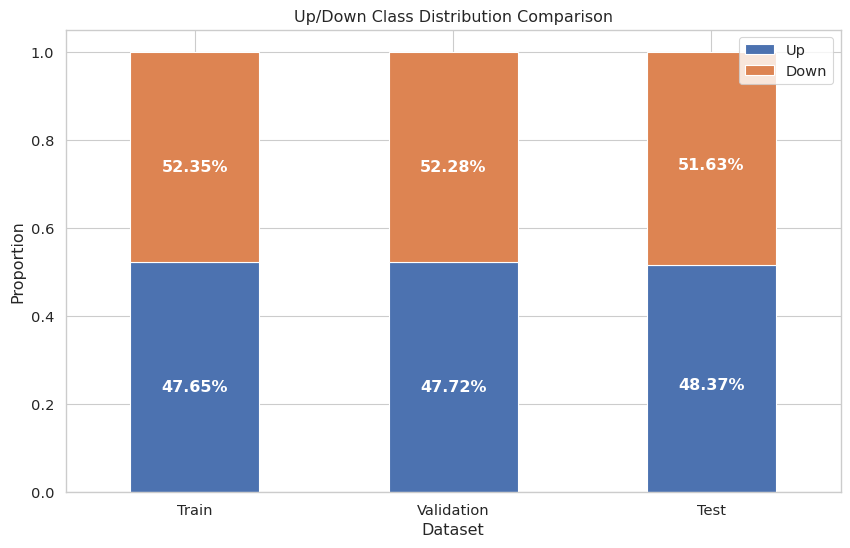

: 

In [ ]:
# --- 2.3. Class Balance Comparison ---
# Motivation: Verifies that the proportion of positive and negative classes is stable.
# A significant imbalance could bias the model.
class_ratios = {name: analyzer.get_class_dist() for name, analyzer in analyzers.items()}
class_df = pd.DataFrame(class_ratios).T.rename(columns={0: 'Down', 1: 'Up'})

class_df.plot(kind='bar', stacked=True, figsize=(10, 6), rot=0)
plt.title('Up/Down Class Distribution Comparison')
plt.ylabel('Proportion')
plt.xlabel('Dataset')
for index, row in enumerate(class_df.itertuples()):
    if row.Down > 0:
        plt.text(index, row.Down / 2, f'{row.Down:.2%}', ha='center', va='center', color='white', weight='bold')
    if row.Up > 0:
        plt.text(index, row.Down + (row.Up / 2), f'{row.Up:.2%}', ha='center', va='center', color='white', weight='bold')
save_figure('cross_dataset_class_distribution')
plt.show()

In [ ]:
# --- 2.4. Connectivity Comparison ---
# Motivation: Compares the overall density of the graphs.
connectivity_scores = {name: analyzer.get_connectivity() for name, analyzer in analyzers.items()}
connectivity_df = pd.DataFrame.from_dict(connectivity_scores, orient='index', columns=['Connectivity'])

plt.figure(figsize=(10, 5))
sns.barplot(x=connectivity_df.index, y=connectivity_df['Connectivity'])
plt.title('Graph Connectivity (Density) Comparison')
plt.ylabel('Connectivity Score')
plt.xlabel('Dataset')
plt.grid(axis='y')
save_figure('cross_dataset_connectivity')
plt.show()

## 3. Deep Feature Analysis (Training Set)

**Motivation**: This section provides a deep dive into the node features of the training set. Understanding these features is essential for feature engineering, interpreting model behavior, and diagnosing potential issues like multicollinearity or lack of predictive power.

--- Feature Statistics (Training Set) ---


,Close,High,Low,Open,Volume
count,149968.000000,149968.000000,149968.000000,149968.000000,149968.000000
mean,3.421892,3.432277,3.410482,3.421569,12.096305
std,0.831928,0.831638,0.832318,0.831996,2.031325
min,0.150157,0.155618,0.146527,0.150172,1.179372
25%,2.922165,2.934223,2.909848,2.921910,10.797283
50%,3.404315,3.415641,3.392049,3.403969,12.080392
75%,3.915604,3.924563,3.906022,3.915289,13.387562
max,10.488404,10.505379,10.474856,10.492373,20.749344



--- LaTeX Table ---
\begin{table}
\caption{Descriptive statistics for node features in the training set.}
\label{tab:feature_stats}
\begin{tabular}{lrrrrr}
\toprule
 & Close & High & Low & Open & Volume \\
\midrule
count & 149968.000 & 149968.000 & 149968.000 & 149968.000 & 149968.000 \\
mean & 3.422 & 3.432 & 3.410 & 3.422 & 12.096 \\
std & 0.832 & 0.832 & 0.832 & 0.832 & 2.031 \\
min & 0.150 & 0.156 & 0.147 & 0.150 & 1.179 \\
25% & 2.922 & 2.934 & 2.910 & 2.922 & 10.797 \\
50% & 3.404 & 3.416 & 3.392 & 3.404 & 12.080 \\
75% & 3.916 & 3.925 & 3.906 & 3.915 & 13.388 \\
max & 10.488 & 10.505 & 10.475 & 10.492 & 20.749 \\
\bottomrule
\end{tabular}
\end{table}

Figure saved to thesis_figures_final/feature_distributions.pdf
Figure saved to thesis_figures_final/feature_distributions.pdf
Figure saved to thesis_figures_final/feature_distributions.pdf


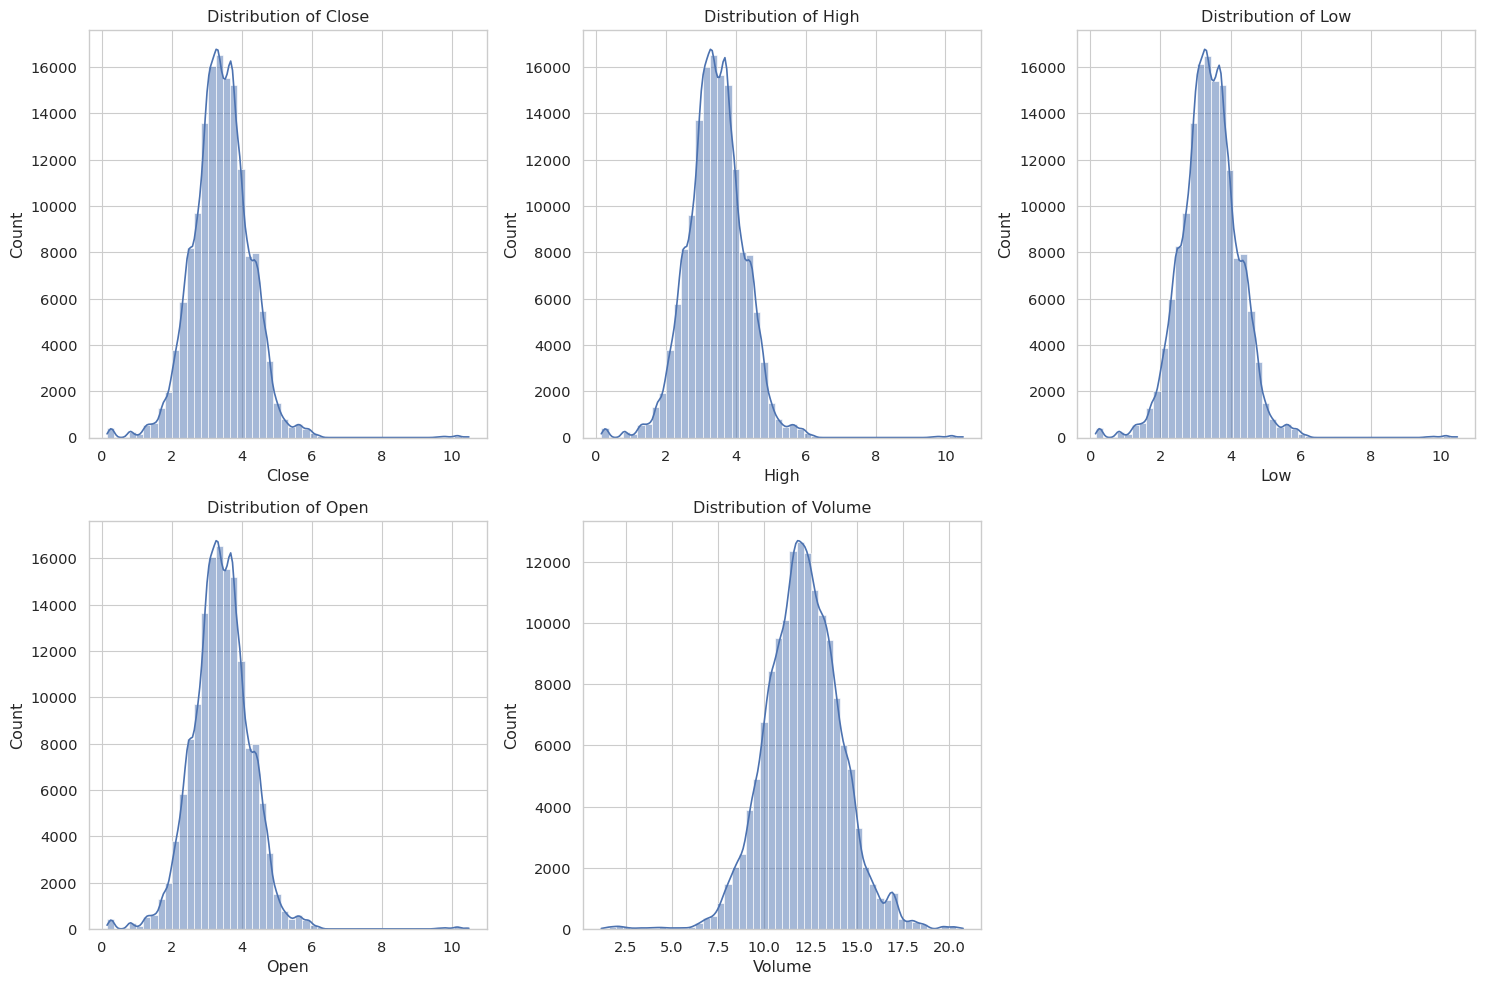

Figure saved to thesis_figures_final/feature_correlation_matrix.pdf


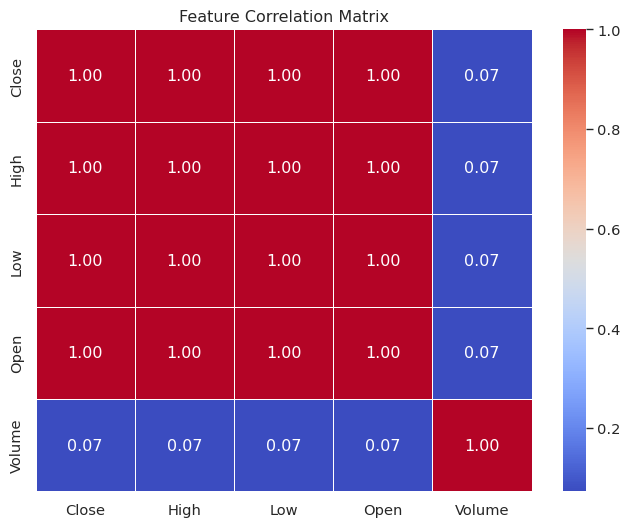

Figure saved to thesis_figures_final/feature_entropy.pdf


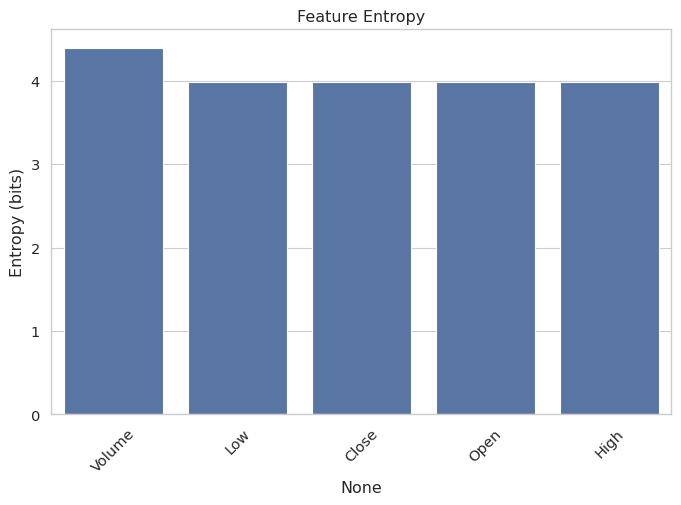

In [2]:
# We focus on the training set for deep feature analysis
features_df = train_analyzer.analyze_node_features()

# --- 3.1. Features Statistical Summary ---
# Motivation: To get a quantitative overview of each feature (e.g., mean, std, range).
feature_stats = features_df[train_analyzer.features].describe()
print("--- Feature Statistics (Training Set) ---")
display(feature_stats)
print("\n--- LaTeX Table ---")
print(feature_stats.to_latex(caption='Descriptive statistics for node features in the training set.', label='tab:feature_stats', float_format="%.3f"))

# --- 3.2. Features Distribution Visualization ---
# Motivation: To visually inspect the shape of each feature's distribution (e.g., normal, skewed, bimodal).
plt.figure(figsize=(15, 10))
for i, feature in enumerate(train_analyzer.features):
    plt.subplot(2, 3, i + 1)
    sns.histplot(features_df[feature], kde=True, bins=50)
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
save_figure('feature_distributions')
plt.show()

# --- 3.3. Feature Correlation ---
# Motivation: To identify linear relationships between features. High correlation indicates redundancy
# and may suggest that feature selection or dimensionality reduction could be beneficial.
correlation_matrix = features_df[train_analyzer.features].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Feature Correlation Matrix')
save_figure('feature_correlation_matrix')
plt.show()

# --- 3.4. Feature Entropy ---
# Motivation: To measure the "informativeness" or unpredictability of each feature.
# Higher entropy implies more information content.
def calculate_entropy(series, bins=50):
    counts = np.histogram(series, bins=bins)[0]
    return entropy(counts, base=2)

feature_entropy = {feat: calculate_entropy(features_df[feat]) for feat in train_analyzer.features}
entropy_series = pd.Series(feature_entropy).sort_values(ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(x=entropy_series.index, y=entropy_series.values)
plt.title('Feature Entropy')
plt.ylabel('Entropy (bits)')
plt.xticks(rotation=45)
save_figure('feature_entropy')
plt.show()

## 4. Graph Structure Analysis (Training Set)

**Motivation**: This section analyzes the graph's topology. The structure of the graph dictates how information propagates during message passing in a GNN, making its properties highly relevant to model performance.

Adjacency matrix shape: (721, 721)
Figure saved to thesis_figures_final/adjacency_matrix_first_snapshot.pdf
Figure saved to thesis_figures_final/adjacency_matrix_first_snapshot.pdf
Figure saved to thesis_figures_final/adjacency_matrix_first_snapshot.pdf


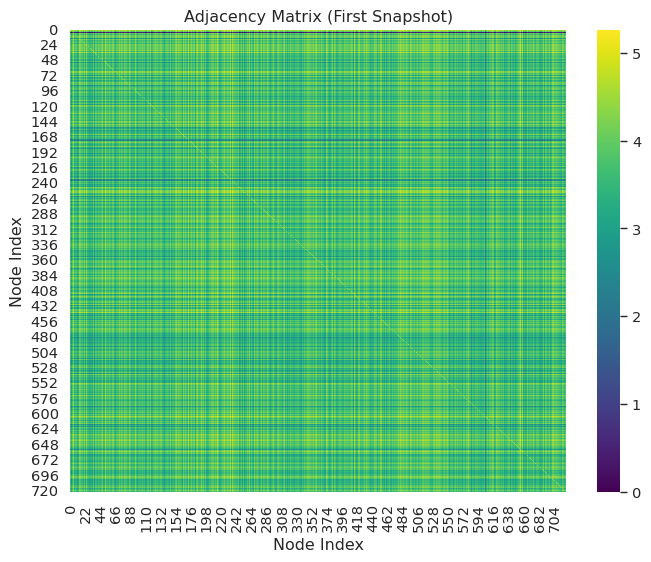

Adjacency matrix shape: (721, 721)
Adjacency matrix shape: (721, 721)
Adjacency matrix shape: (721, 721)
Adjacency matrix shape: (721, 721)
Adjacency matrix shape: (721, 721)
Adjacency matrix shape: (721, 721)
Adjacency matrix shape: (721, 721)
--- Graph Sparsity ---
--- Graph Sparsity ---
--- Graph Sparsity ---


,Sparsity
Dataset,
Train,0.000004
Validation,0.000010
Test,0.000007


Figure saved to thesis_figures_final/edge_weight_distribution.pdf


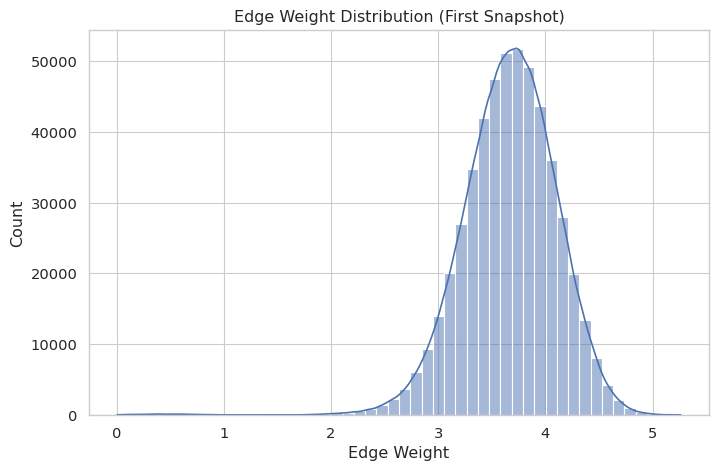

In [ ]:
# --- 4.1. Adjacency Matrix Visualization, Sparsity, and Edge Weights ---
# Motivation: To get a visual sense of the graph's connectivity and to quantify its sparsity.
# The edge weight distribution reveals the nature of the connections.
adj_matrices = train_analyzer.get_snapshots_adjacency_matrix()

# Visualize First Adjacency Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(adj_matrices[0], cmap='viridis')
plt.title('Adjacency Matrix (First Snapshot)')
plt.xlabel('Node Index')
plt.ylabel('Node Index')
save_figure('adjacency_matrix_first_snapshot')
plt.show()

# Sparsity Analysis
sparsity_data = []
for name, analyzer in analyzers.items():
    adjs = analyzer.get_snapshots_adjacency_matrix()
    sparsity = 1.0 - np.mean([np.count_nonzero(adj) / adj.size for adj in adjs])
    sparsity_data.append({'Dataset': name, 'Sparsity': sparsity})
sparsity_df = pd.DataFrame(sparsity_data).set_index('Dataset')
print("--- Graph Sparsity ---")
display(sparsity_df)

# Edge Weight Distribution
edge_weights = adj_matrices[0][adj_matrices[0] > 0].flatten()
plt.figure(figsize=(8, 5))
sns.histplot(edge_weights, bins=50, kde=True)
plt.title('Edge Weight Distribution (First Snapshot)')
plt.xlabel('Edge Weight')
save_figure('edge_weight_distribution')
plt.show()

# --- 4.2. Degree Distributions (In, Out, Weighted) ---
# Motivation: To understand the connectivity patterns. A power-law-like distribution,
# common in real-world networks, indicates the presence of important hub nodes.
# Unweighted (Absolute) Degree Distribution
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Unweighted Degree Distribution (Train Set)', fontsize=16)
in_degrees, out_degrees, _, _ = train_analyzer.get_degree_dist()
sns.kdeplot(in_degrees, ax=axes[0], fill=True, alpha=0.5, label='In-Degree')
axes[0].set_title('In-Degree Distribution')
sns.kdeplot(out_degrees, ax=axes[1], fill=True, alpha=0.5, label='Out-Degree', color='orange')
axes[1].set_title('Out-Degree Distribution')
save_figure('unweighted_degree_distribution_train')
plt.show()

# Weighted Degree Distribution
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Weighted Degree Distribution (Train Set)', fontsize=16)
_, _, weighted_in_degrees, weighted_out_degrees = train_analyzer.get_degree_dist()
sns.kdeplot(weighted_in_degrees, ax=axes[0], fill=True, alpha=0.5, label='Weighted In-Degree')
axes[0].set_title('Weighted In-Degree Distribution')
sns.kdeplot(weighted_out_degrees, ax=axes[1], fill=True, alpha=0.5, label='Weighted Out-Degree', color='orange')
axes[1].set_title('Weighted Out-Degree Distribution')
save_figure('weighted_degree_distribution_train')
plt.show()


# --- 4.3. Connectivity and Clustering Metrics ---
# Motivation: To measure the graph's cohesiveness. A single large connected component is desirable.
# The clustering coefficient measures the tendency of nodes to form local clusters.
graph_metrics_data = []
for name, analyzer in analyzers.items():
    adj = analyzer.get_snapshots_adjacency_matrix()[0] # Analyze first snapshot for simplicity
    G = nx.from_numpy_array(adj, create_using=nx.DiGraph)
    
    # For undirected metrics, convert to undirected graph
    G_undirected = G.to_undirected()
    
    metrics = {
        'Dataset': name,
        'Num Weakly Connected Components': nx.number_weakly_connected_components(G),
        'Largest WCC Size': len(max(nx.weakly_connected_components(G), key=len)),
        'Avg. Clustering Coeff.': nx.average_clustering(G, weight='weight')
    }
    graph_metrics_data.append(metrics)

graph_metrics_df = pd.DataFrame(graph_metrics_data).set_index('Dataset')
print("--- Graph Connectivity and Clustering Metrics ---")
display(graph_metrics_df)

## 5. Temporal Analysis

**Motivation**: To confirm that the dataset has dynamic properties that change over time. If the graph structure and features were static, a simpler, non-temporal GNN would be sufficient. This analysis justifies the use of a temporal GNN.

Adjacency matrix shape: (128, 128)
Figure saved to thesis_figures_final/temporal_adj_stability.pdf
Figure saved to thesis_figures_final/temporal_adj_stability.pdf
Figure saved to thesis_figures_final/temporal_adj_stability.pdf


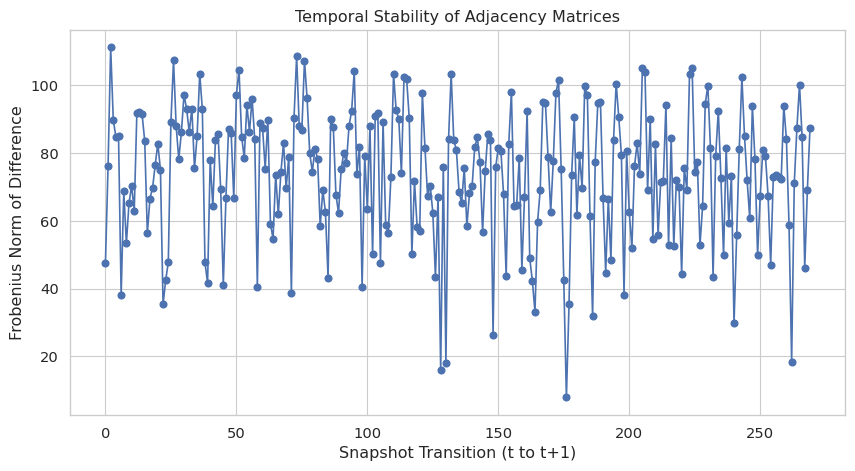

Figure saved to thesis_figures_final/temporal_feature_trend.pdf


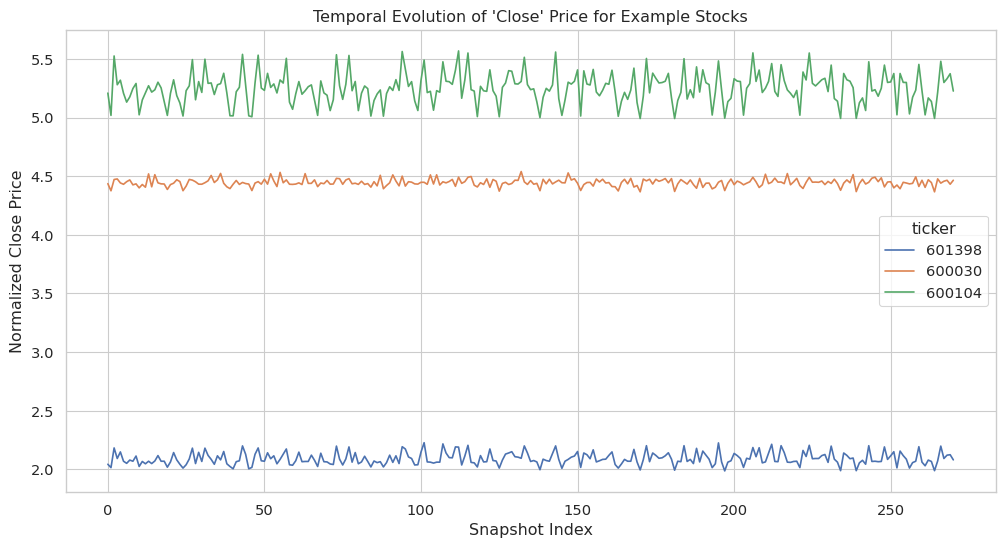

In [ ]:
# --- 5.1. Adjacency Matrix Stability ---
# Motivation: To quantify how much the graph structure changes between snapshots.
# A volatile plot indicates a highly dynamic graph.
adj_matrices = train_analyzer.get_snapshots_adjacency_matrix()
adj_diffs = []
for i in range(1, len(adj_matrices)):
    diff = np.linalg.norm(adj_matrices[i] - adj_matrices[i-1], 'fro')
    adj_diffs.append(diff)

plt.figure(figsize=(10, 5))
plt.plot(adj_diffs, marker='o', linestyle='-')
plt.title('Temporal Stability of Adjacency Matrices')
plt.xlabel('Snapshot Transition (t to t+1)')
plt.ylabel('Frobenius Norm of Difference')
save_figure('temporal_adj_stability')
plt.show()

# --- 5.2. Feature Trend Over Time ---
# Motivation: To visualize how node features evolve, confirming their non-stationary nature.
example_stocks = [train_analyzer.index_to_stock[i] for i in [0, 10, 20] if i < train_analyzer.num_nodes]
ts_data = pd.DataFrame()
for stock in example_stocks:
    stock_ts = train_analyzer.get_feature_timeseries(stock_ticker=stock, feature='Close')
    ts_data = pd.concat([ts_data, stock_ts])

if not ts_data.empty:
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=ts_data, x='snapshot', y='value', hue='ticker')
    plt.title('Temporal Evolution of \'Close\' Price for Example Stocks')
    plt.xlabel('Snapshot Index')
    plt.ylabel('Normalized Close Price')
    save_figure('temporal_feature_trend')
    plt.show()

## 6. Homophily Analysis

**Motivation**: Homophily is the principle that similar nodes tend to connect with each other. In our context, it measures whether stocks that go "Up" tend to be connected to other "Up" stocks (and vice-versa). A high homophily score suggests that neighbor information is strongly indicative of a node's own class, which is a favorable condition for GNNs. Heterophily (the opposite) presents a greater challenge.

Figure saved to thesis_figures_final/temporal_homophily.pdf


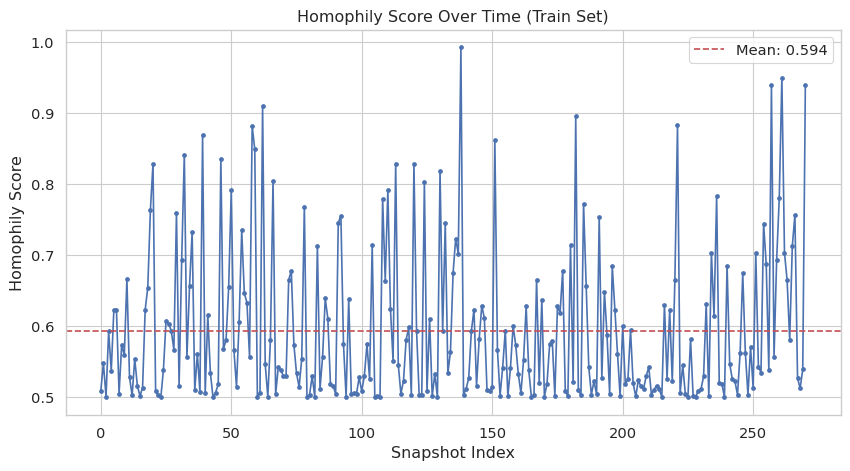

Average Homophily Score: 0.5935
Std Dev of Homophily: 0.1081


In [ ]:
# --- 6.1. Homophily Score Over Time ---
# Motivation: To see if the level of homophily is stable or dynamic.
homophily_scores = [train_analyzer.get_homophily_score(i) for i in range(train_analyzer.num_snapshots)]

plt.figure(figsize=(10, 5))
plt.plot(homophily_scores, marker='.', linestyle='-')
plt.title('Homophily Score Over Time (Train Set)')
plt.xlabel('Snapshot Index')
plt.ylabel('Homophily Score')
plt.axhline(y=np.mean(homophily_scores), color='r', linestyle='--', label=f'Mean: {np.mean(homophily_scores):.3f}')
plt.legend()
save_figure('temporal_homophily')
plt.show()

print(f"Average Homophily Score: {np.mean(homophily_scores):.4f}")
print(f"Std Dev of Homophily: {np.std(homophily_scores):.4f}")